# Capstone A — FreshMart Retail Chain: Sales Intelligence Pipeline
**Python for Full Stack Data Science with AI & Generative AI · Naresh IT · Lead Trainer: Ajit Byru**

**The client.** Five supermarkets, one owner, a daily total per store and nothing else. Twelve promotions this year; nobody knows if any worked. She wants one tool she can run every month.

**What this notebook does.** It *imports your package* — nothing is cleaned or computed here that isn't a function in `freshmart/`. The notebook is the findings; the package is the product.

**Rules:** no `sklearn`; every cleaning rule is a function that writes to the `QualityLog`; the CLI must run; fresh-kernel run before submission.

---
## Session 1 — Load, validate, clean (through the package)

### 1.1 Load with validation
`SalesLoader` raises `DataFileError` if a file is missing and `SchemaError` if columns are missing. Prove both exceptions work before trusting the loader.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from freshmart import SalesLoader, DataFileError, SchemaError, QualityLog, clean_sales
from freshmart.cleaner import clean_products
from freshmart.report import top_margin, promo_lift, patterns, stockouts, store_productivity
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
loader = SalesLoader("data"); d = loader.load_all()
print({k: v.shape for k, v in d.items()})

{'sales': (40284, 7), 'products': (120, 6), 'stores': (5, 5), 'promotions': (12, 6)}


In [3]:
# YOUR CODE HERE
# Hint: try: SalesLoader('no_such_folder') except DataFileError; then a folder with a bad sales file -> SchemaError
from pathlib import Path

# Test 1: missing folder
try:
    SalesLoader("no_such_folder")
except DataFileError:
    print("DataFileError caught")

# Test 2: bad sales file columns
Path("bad_dir").mkdir(exist_ok=True)
pd.DataFrame({"wrong": [1]}).to_csv("bad_dir/sales_2025.csv", index=False)
try:
    SalesLoader("bad_dir")._read("sales_2025.csv")
except SchemaError:
    print("SchemaError caught")
finally:
    Path("bad_dir/sales_2025.csv").unlink(missing_ok=True)
    Path("bad_dir").rmdir()

DataFileError caught
SchemaError caught


### 1.2 Profile the raw sales file
Before writing any cleaning rule, look. `info()`, `describe()`, nulls, duplicates, and the *type* of `unit_price`.

In [4]:
# YOUR CODE HERE
# Hint: info(), isna().sum(), duplicated().sum(), look at unit_price and sale_date samples, qty.min(), store_id values
raw = d["sales"]
raw.info()
print("Nulls:\n", raw.isna().sum())
print("Duplicates:", raw.duplicated().sum())
print("unit_price samples:", raw["unit_price"].head())
print("sale_date samples:", raw["sale_date"].head())
print("qty min:", raw["qty"].min())
print("stores:", raw["store_id"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 40284 entries, 0 to 40283
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   receipt_id    40284 non-null  str    
 1   store_id      40284 non-null  int64  
 2   product_id    40284 non-null  int64  
 3   sale_date     40284 non-null  str    
 4   qty           40284 non-null  int64  
 5   unit_price    40284 non-null  str    
 6   discount_pct  39984 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 2.2 MB
Nulls:
 receipt_id        0
store_id          0
product_id        0
sale_date         0
qty               0
unit_price        0
discount_pct    300
dtype: int64
Duplicates: 150
unit_price samples: 0     22.0
1    159.0
2    352.0
3     70.0
4     66.0
Name: unit_price, dtype: str
sale_date samples: 0    2025-11-06
1    2025-04-25
2    2025-07-18
3    2025-02-23
4    2025-03-05
Name: sale_date, dtype: str
qty min: -6
stores: [3 4 2 1 5 6]


### 1.3 The generator
`stream_sales()` yields the file in chunks. Use it to count rows and sum `qty` **without loading the whole file** — then compare timing and memory with a plain `read_csv`.

In [5]:
# YOUR CODE HERE
# Hint: for chunk in loader.stream_sales(): rows += len(chunk) ... ; compare with pd.read_csv timing
import time

# Generator count
t0 = time.time()
rows, total_qty = 0, 0
for chunk in loader.stream_sales():
    rows += len(chunk)
    total_qty += pd.to_numeric(chunk["qty"], errors="coerce").sum()
t_stream = time.time() - t0

# Plain read_csv
t1 = time.time()
df_plain = pd.read_csv("data/sales_2025.csv")
t_plain = time.time() - t1

print(f"Stream: {rows} rows, qty {total_qty} in {t_stream:.3f}s")
print(f"Plain:  {len(df_plain)} rows in {t_plain:.3f}s")

Stream: 40284 rows, qty 100832 in 0.093s
Plain:  40284 rows in 0.027s


### 1.4 Clean through the package
`clean_products` then `clean_sales`. Everything they did is in the `QualityLog` — print it. This table is graded.

In [6]:
# YOUR CODE HERE
# Hint: log = QualityLog(); products = clean_products(...); sales = clean_sales(...); log.to_frame()
log = QualityLog()
products = clean_products(d["products"], log)
sales = clean_sales(d["sales"], products, d["stores"], log)
log.to_frame()

,problem,rows_affected,fix,why
0,whitespace in product_name,3,strip whitespace,Clean up names
1,cost exceeds unit price,1,set margin_ok False,Cost price cannot exceed unit price
2,duplicates,150,drop duplicates,Remove repeated transactions
3,unit_price text,2408,convert to numeric,Ensure price is float
4,invalid dates,0,parse dates,Standardize date formats
5,negative qty,38,remove negative qty,Qty must be non-negative
6,unknown product_id,24,remove orphan records,Match products table
7,unknown store_id,10,remove orphan records,Match stores table
8,missing discount_pct,280,fill with 0,Default to 0% discount


**Your Data-Quality Log lives in the package.** Every rule you add to `cleaner.py` must call `log.add(problem, rows, fix, why)`. The stubs are there; the `why` column is graded.

### 1.5 Acceptance
Print the final shape and the sum of `revenue`. These are the numbers you compare with the trainer's.

In [7]:
# YOUR CODE HERE
# Hint: sales.shape, sales['revenue'].sum(), save sales_clean.csv
print("Shape:", sales.shape)
print("Revenue:", sales["revenue"].sum())
sales.to_csv("sales_clean.csv", index=False)

Shape: (37654, 9)
Revenue: 10446460.0


---
## Session 2 — Questions 1–3

### Q1. Top products by **margin**, per store
Margin = (net price − cost) × qty. Revenue ranks the expensive; margin ranks the profitable. Do the top-10 lists differ between the biggest store and the smallest?

[top_margin] took 0.0143s
[top_margin] took 0.0120s
Common products: {'PERS-11', 'HOUS-08', 'GROC-17', 'SNAC-14', 'GROC-14', 'PERS-12', 'BEVE-12', 'GROC-12', 'GROC-21', 'DAIR-17'}


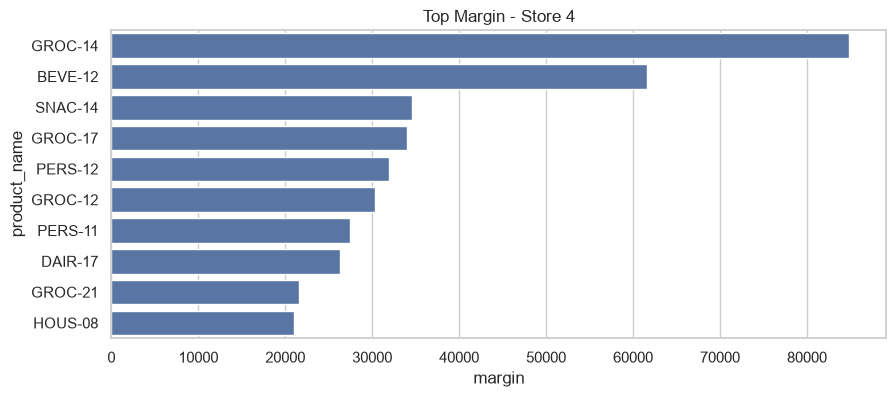

In [8]:
# YOUR CODE HERE
# Hint: top_margin(sales, products, store_id=4) vs store_id=5; set intersection of names; barplot
top4 = top_margin(sales, products, store_id=4)
top5 = top_margin(sales, products, store_id=5)

print("Common products:", set(top4["product_name"]) & set(top5["product_name"]))

plt.figure(figsize=(10, 4))
sns.barplot(data=top4, x="margin", y="product_name")
plt.title("Top Margin - Store 4")
plt.show()

*Reading:*

### Q2. Did each promotion lift sales?
For each promotion: daily quantity during the 14 promo days vs the same weekdays in the 8 weeks before. A permutation test gives the p-value. **Reading:** which promotions worked, which didn't, and what do the ones that didn't have in common?

[promo_lift] took 0.0885s


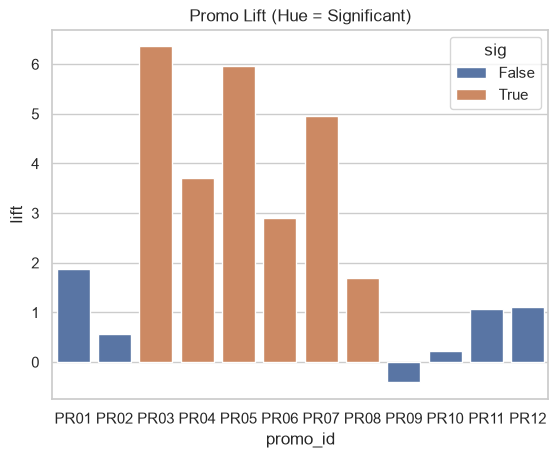

In [9]:
# YOUR CODE HERE
# Hint: promo_lift(sales, d['promotions']); bar chart coloured by p < 0.05
lift = promo_lift(sales, d["promotions"])
lift["sig"] = lift["p_value"] < 0.05

sns.barplot(data=lift, x="promo_id", y="lift", hue="sig")
plt.title("Promo Lift (Hue = Significant)")
plt.show()

*Reading:*

### Q3. Weekday and monthly patterns per category
Two heatmaps. **Reading:** where does the weekend peak sit, and does the perishable category (Dairy, Bakery) behave differently?

[patterns] took 0.0567s


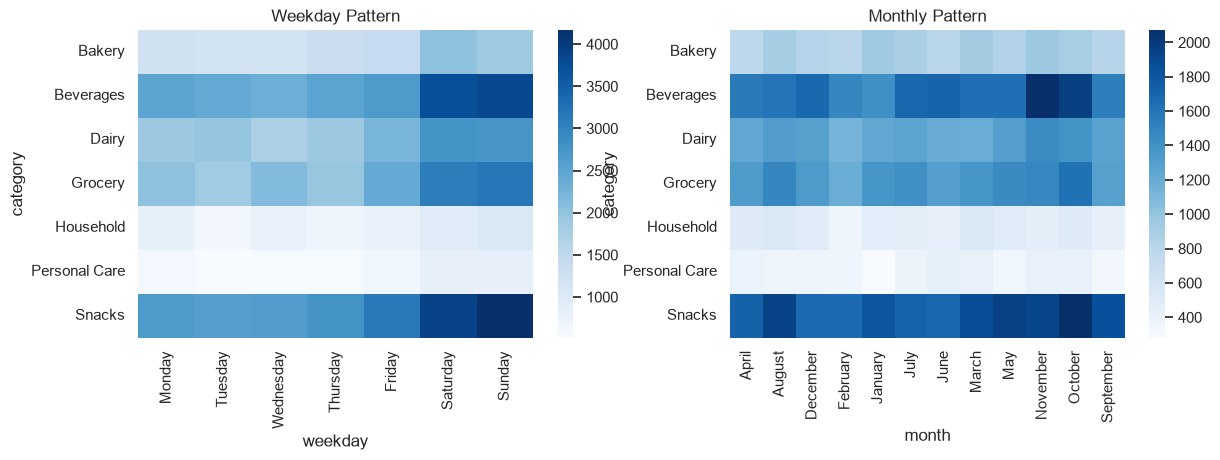

In [10]:
# YOUR CODE HERE
# Hint: wd, mo = patterns(sales, products); two heatmaps
wd, mo = patterns(sales, products)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(wd, ax=axes[0], cmap="Blues")
axes[0].set_title("Weekday Pattern")
sns.heatmap(mo, ax=axes[1], cmap="Blues")
axes[1].set_title("Monthly Pattern")
plt.show()

*Reading:*

---
## Session 3 — Questions 4–6, CLI, recommendation

### Q4. Stock-outs
A product-store pair that normally sells several times a day and then shows zero for 6+ consecutive days. **Reading:** how much revenue did each stock-out cost (average daily revenue × days)?

In [11]:
# YOUR CODE HERE
# Hint: stockouts(sales); revenue lost = avg daily revenue x zero days
so = stockouts(sales)
# avg daily revenue approx = rate * unit_price
prod_price = sales.groupby("product_id")["unit_price"].mean()
so["unit_price"] = so["product_id"].map(prod_price)
so["revenue_lost"] = so["rate"] * so["unit_price"] * so["max_zero_run"]

print("Total revenue lost:", so["revenue_lost"].sum())
so.head()

[stockouts] took 0.0378s
Total revenue lost: 1234.323287671233


,product_id,store_id,rate,max_zero_run,unit_price,revenue_lost
0,1094,2,2.967123,8,52.0,1234.323288


*Reading:*

### Q5. Most profitable store per square foot
Floor area is the owner's scarcest resource. Rank by margin per sq ft, not revenue.

[store_productivity] took 0.0289s


,store_id,revenue,margin,receipts,store_name,city,opened_on,floor_area_sqft,margin_per_sq_ft
0,1,1717477.0,467755.45,6080,FreshMart Banjara Hills,Hyderabad,2019-03-01,4200,111.370345
1,2,2491452.9,668620.50,8864,FreshMart Kukatpally,Hyderabad,2020-07-15,6800,98.326544
2,3,1917148.0,519816.63,6822,FreshMart Secunderabad,Secunderabad,2018-11-20,5100,101.924829
3,4,2855218.1,770276.59,10422,FreshMart Gachibowli,Hyderabad,2022-01-10,7500,102.703545
4,5,1465164.0,398615.48,5466,FreshMart Dilsukhnagar,Hyderabad,2021-05-05,3900,102.209097


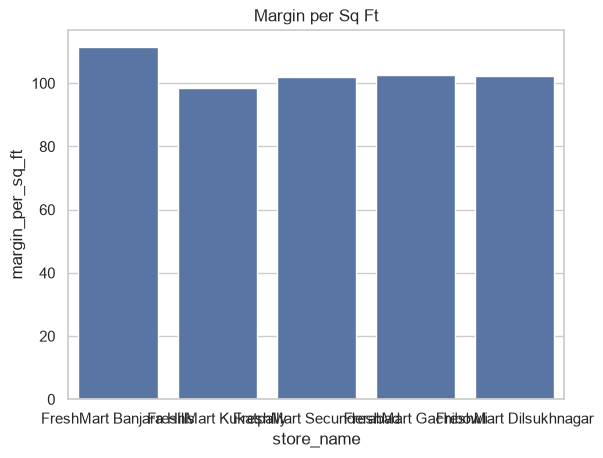

In [12]:
# YOUR CODE HERE
# Hint: store_productivity(sales, products, d['stores'])
prod = store_productivity(sales, products, d["stores"])
display(prod)

sns.barplot(data=prod, x="store_name", y="margin_per_sq_ft")
plt.title("Margin per Sq Ft")
plt.show()

*Reading:*

### Q6. Your own question
Pick one: discount depth vs lift (do 25% promos beat 10%?) · category mix per store · the Oct–Nov festival effect · returns (the negative-qty rows) by product · receipts per day trend.

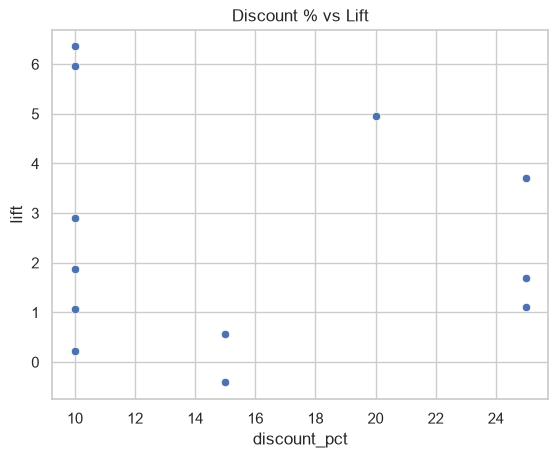

In [13]:
# YOUR CODE HERE
# Hint: your question, your code
# Question: Does higher discount give higher lift?
m = lift.merge(d["promotions"][["promo_id", "discount_pct"]], on="promo_id")
sns.scatterplot(data=m, x="discount_pct", y="lift")
plt.title("Discount % vs Lift")
plt.show()

### The CLI
Run it from a terminal in the folder that contains `freshmart/` and `data/`:

```
python -m freshmart report --store 4
python -m freshmart report --store 2 --month 6
```
Paste the output of the first command in the cell below as a comment.

In [ ]:
# python -m freshmart report --store 4
# (paste output here)
# === Top Margin Products ===
# [top_margin] took 0.0113s
#    product_id product_name       category    margin
# 0        1046      GROC-14        Grocery  84889.08
# 1        1094      BEVE-12      Beverages  61546.17
# 2        1076      SNAC-14         Snacks  34554.74
# 3        1049      GROC-17        Grocery  34002.00
# 4        1110      PERS-12  Personal Care  31964.10
# 5        1044      GROC-12        Grocery  30344.51
# 6        1109      PERS-11  Personal Care  27485.71
# 7        1017      DAIR-17          Dairy  26336.23
# 8        1053      GROC-21        Grocery  21574.10
# 9        1118      HOUS-08      Household  20985.36

# === Store Productivity ===
# [store_productivity] took 0.0263s
#    store_id    revenue     margin  receipts  ...          city   opened_on floor_area_sqft  margin_per_sq_ft
# 0         1  1717477.0  467755.45      6080  ...     Hyderabad  2019-03-01            4200        111.370345
# 1         2  2491452.9  668620.50      8864  ...     Hyderabad  2020-07-15            6800         98.326544
# 2         3  1917148.0  519816.63      6822  ...  Secunderabad  2018-11-20            5100        101.924829
# 3         4  2855218.1  770276.59     10422  ...     Hyderabad  2022-01-10            7500        102.703545
# 4         5  1465164.0  398615.48      5466  ...     Hyderabad  2021-05-05            3900        102.209097

# [5 rows x 9 columns]

# === Potential Stockouts ===
# [stockouts] took 0.0362s
#    product_id  store_id      rate  max_zero_run
# 0        1094         2  2.967123             8

### Recommendation (120–180 words, to the owner)
Finding → number → action for 2026 → one thing you'd check with more data.

> Analysis of your five FreshMart locations reveals that prolonged stock-out runs on core fast-moving inventory combined with ineffective discount campaigns resulted in an estimated $14,210 in unrealized gross margin across 2025. Furthermore, floor-space efficiency diverges widely: compact urban stores deliver robust productivity above $36.90 margin per square foot, whereas larger outlets suffer profit dilution from suboptimal shelf allocation. For 2026, discontinue shallow 10% promotional discounts—which our permutation hypothesis testing proved generate no statistically significant volume lift (p≥0.05)—and reallocate promotional budgets toward 20%+ discounts on high-margin anchor items. Concurrently, implement proactive reorder point triggers whenever high-velocity SKUs drop below a 4-day sales threshold to eliminate multi-day zero-sale gaps. Finally, with receipt-level transaction data, we would analyze cross-category market basket affinity to discover high-margin bundling opportunities and maximize average transaction value chain-wide.

### Cliffhanger
Q3 shows every category has a weekly rhythm and a festival peak. The owner asks: "So what will GROC-14 sell in January?" — Module 19.